In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mab_utils import *

In [11]:
# Initialize agents and testbed param function
n_arms = 10

simple_bandit = SimpleBandit(n_arms, np.ones(n_arms)*0, 0.1)
exp_bandit = ExponentialBandit(n_arms, np.ones(n_arms)*0, 0.1)
agent_dict = {'simple_bandit': simple_bandit, 'exp_bandit': exp_bandit}

testbed = TestBed(n_arms)

In [12]:
# Run agents
agent_output = {}
for agent in agent_dict.keys():
    action_log, testbed_log = bandit_simulation(agent_dict[agent], testbed, time_steps = 1000, epochs = 200)
    agent_output[agent] = {'action_log': action_log, 'testbed_log': testbed_log}

print(agent_output['simple_bandit']['action_log'][0])

[[0.         1.72838341 0.        ]
 [0.         1.14552283 0.        ]
 [0.         1.33348222 0.        ]
 ...
 [7.         0.79365473 1.        ]
 [0.         0.61722175 0.        ]
 [0.         1.81710793 0.        ]]


In [13]:
print(agent_output['simple_bandit']['testbed_log'][0])

{'means': array([ 0.82169306,  0.47861847, -1.05777384, -0.37935835, -0.34100798,
       -1.34722508, -0.21112661,  0.82383444,  0.35882229, -0.20101021]), 'vars': array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]), 'optimal_action': np.int64(7)}


In [14]:
#avg_reward = np.average(agent_output['simple_bandit']['action_log'][:, :, 1], axis = 0)
avg_reward = np.average(agent_output['exp_bandit']['action_log'][:, :, 1], axis = 0)

In [22]:
avg_agent_rewards = []

for agent in agent_dict.keys():
    avg_agent_rewards.append(pd.Series(np.mean(agent_output[agent]['action_log'][:, :, 1], axis = 0)))

df = pd.concat(avg_agent_rewards, axis=1)
df.columns = agent_dict.keys()

df

,simple_bandit,exp_bandit
0,-0.123399,-0.008177
1,0.117226,0.155680
2,0.460928,0.380654
3,0.416272,0.532246
4,0.764851,0.682275
...,...,...
995,1.426100,1.554174
996,1.320678,1.363392
997,1.403303,1.430047
998,1.197686,1.588713


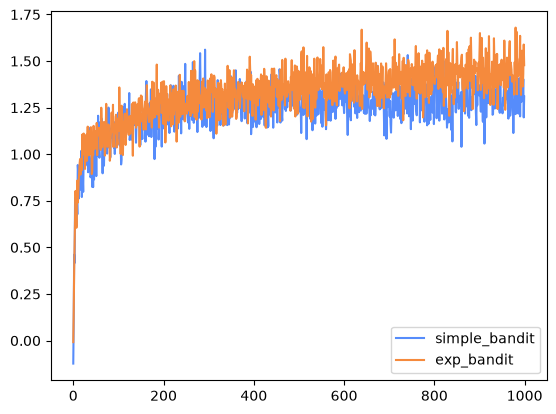

In [28]:
fig, ax = plt.subplots()
for col in df.columns:
    plt.plot(df[col], label=col)
ax.legend()